In [1]:
import numpy as np
import torch
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import pandas as pd
import os
import re
import polars as pl
from collections import defaultdict
import matplotlib.gridspec as gridspec

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
mc_path = "/home/aegis/Titan1/NRAD/data/Regions_MC"
data_path = "/home/aegis/Titan1/NRAD/data/Regions_data_ver2"

mc_processes = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]

raw_weights = ["raw_weights", "weight_ngen", "weight_sub_weight", "weight_tot_weight"]
SCALAR_VARS = ["met_recalc_pt", "met_recalc_phi"]
VECTOR_VARS = [
    "AnalysisJetsAuxDyn_pt", "AnalysisJetsAuxDyn_eta", "AnalysisJetsAuxDyn_phi", 
    "AnalysisLargeRJetsAuxDyn_pt", "AnalysisLargeRJetsAuxDyn_eta", "AnalysisLargeRJetsAuxDyn_phi",
    "AnalysisLargeRJetsAuxDyn_Tau1_wta", "AnalysisLargeRJetsAuxDyn_Tau2_wta", "AnalysisLargeRJetsAuxDyn_Tau3_wta"
]

columns_to_load_mc = raw_weights + SCALAR_VARS + VECTOR_VARS
columns_to_load_data = SCALAR_VARS + VECTOR_VARS

### Check MC Distributions

In [3]:
MC_CR1L_paths = glob.glob(os.path.join(mc_path, "CR_1L", "*.parquet"))
MC_CR1L1B_paths = glob.glob(os.path.join(mc_path, "CR_1L1B", "*.parquet"))
MC_CR2L_paths = glob.glob(os.path.join(mc_path, "CR_2L", "*.parquet"))
MC_CR0L_paths = glob.glob(os.path.join(mc_path, "CR_MJRR", "*.parquet"))

print("W+jets dominated background (CR1L) files", len(MC_CR1L_paths))
print("Top dominated background (CR1L1B) files", len(MC_CR1L1B_paths))
print("Z+jets dominated background (CR2L) files", len(MC_CR2L_paths))
print("Multijet dominated background (CR0L) files", len(MC_CR0L_paths))

print()
print("="*50)
print()

DATA_CR1L_paths = glob.glob(os.path.join(data_path, "CR_1L", "*.parquet"))
DATA_CR1L1B_paths = glob.glob(os.path.join(data_path, "CR_1L1B", "*.parquet"))
DATA_CR2L_paths = glob.glob(os.path.join(data_path, "CR_2L", "*.parquet"))
DATA_CR0L_paths = glob.glob(os.path.join(data_path, "CR_MJRR", "*.parquet"))

print("W+jets dominated background (CR1L) data files", len(DATA_CR1L_paths))
print("Top dominated background (CR1L1B) data files", len(DATA_CR1L1B_paths))
print("Z+jets dominated background (CR2L) data files", len(DATA_CR2L_paths))
print("Multijet dominated background (CR0L) data files", len(DATA_CR0L_paths))

W+jets dominated background (CR1L) files 2894
Top dominated background (CR1L1B) files 2610
Z+jets dominated background (CR2L) files 2074
Multijet dominated background (CR0L) files 3062


W+jets dominated background (CR1L) data files 36126
Top dominated background (CR1L1B) data files 36122
Z+jets dominated background (CR2L) data files 23188
Multijet dominated background (CR0L) data files 36465


In [4]:
def calc_features(lf: pl.LazyFrame, is_MC) -> pl.LazyFrame:
    """
    Calculates only HT, Mjj, and tau ratios, then discards all low-level vectors.
    """
    # 1. Extract the specific elements we need from the arrays
    lf = lf.with_columns(
        # HT: Scalar sum of all jet pt
        ht = pl.col("AnalysisJetsAuxDyn_pt").list.sum() / 1000.0,
        
        # Leading and Subleading Jet Kinematics for Mjj
        j1_pt = pl.col("AnalysisJetsAuxDyn_pt").list.get(0),
        j2_pt = pl.col("AnalysisJetsAuxDyn_pt").list.get(1),
        j1_eta = pl.col("AnalysisJetsAuxDyn_eta").list.get(0),
        j2_eta = pl.col("AnalysisJetsAuxDyn_eta").list.get(1),
        j1_phi = pl.col("AnalysisJetsAuxDyn_phi").list.get(0),
        j2_phi = pl.col("AnalysisJetsAuxDyn_phi").list.get(1),
        
        # Large-R Jet Taus (Index 0 is Lead, Index 1 is Sublead)
        lrj1_t1 = pl.col("AnalysisLargeRJetsAuxDyn_Tau1_wta").list.get(0),
        lrj1_t2 = pl.col("AnalysisLargeRJetsAuxDyn_Tau2_wta").list.get(0),
        lrj1_t3 = pl.col("AnalysisLargeRJetsAuxDyn_Tau3_wta").list.get(0),
        lrj2_t1 = pl.col("AnalysisLargeRJetsAuxDyn_Tau1_wta").list.get(1),
        lrj2_t2 = pl.col("AnalysisLargeRJetsAuxDyn_Tau2_wta").list.get(1),
        lrj2_t3 = pl.col("AnalysisLargeRJetsAuxDyn_Tau3_wta").list.get(1),
    )

    # 2. Calculate the final complex math
    lf = lf.with_columns(
        # Mjj formula
        mjj = (
            2 * pl.col("j1_pt") * pl.col("j2_pt") * ((pl.col("j1_eta") - pl.col("j2_eta")).cosh() - (pl.col("j1_phi") - pl.col("j2_phi")).cos())
        ).sqrt() / 1000.0,
        
        # Subjettiness ratios (with safe division)
        ljet1_tau21 = pl.when(pl.col("lrj1_t1") > 0).then(pl.col("lrj1_t2") / pl.col("lrj1_t1")).otherwise(0),
        ljet1_tau32 = pl.when(pl.col("lrj1_t2") > 0).then(pl.col("lrj1_t3") / pl.col("lrj1_t2")).otherwise(0),
        ljet2_tau21 = pl.when(pl.col("lrj2_t1") > 0).then(pl.col("lrj2_t2") / pl.col("lrj2_t1")).otherwise(0),
        ljet2_tau32 = pl.when(pl.col("lrj2_t2") > 0).then(pl.col("lrj2_t3") / pl.col("lrj2_t2")).otherwise(0),
    )

    # 3. KEEP ONLY WHAT YOU ASKED FOR. Everything else is flushed from memory.
    if is_MC:
        final_columns = [
            "mc_process", "subprocess",                                              # Labels
            "raw_weights", "weight_ngen", "weight_sub_weight", "weight_tot_weight",  # Weights
            "met_recalc_pt", "met_recalc_phi",                                       # MET
            "ht", "mjj",                                                             # Global Kinematics
            "ljet1_tau21", "ljet1_tau32", "ljet2_tau21", "ljet2_tau32"               # Subjettiness
        ]
    else:
        final_columns = [                                                            # Labels
            "met_recalc_pt", "met_recalc_phi",                                       # MET
            "ht", "mjj",                                                             # Global Kinematics
            "ljet1_tau21", "ljet1_tau32", "ljet2_tau21", "ljet2_tau32"               # Subjettiness
        ]
    return lf.select(final_columns)

def get_lazyframes(paths, is_mc):
    # Move this OUTSIDE the loop so it doesn't overwrite on every iteration
    files_by_meta = defaultdict(list)
    known_processes = ['Wjets', 'Zjets', 'ttbar', 'Diboson', 'Multijet', 'Single_top']
    
    for filepath in paths:
        filename = os.path.basename(filepath)
        
        if is_mc:
            # Identify the main mc_process
            mc_process = next((p for p in known_processes if filename.startswith(p)), "Other")
            
            # Clean the filename to extract just the subprocess
            name_no_ext = filename.replace(".parquet", "")
            
            if name_no_ext.startswith(mc_process + "_"):
                remainder = name_no_ext[len(mc_process) + 1:]
            else:
                remainder = name_no_ext
                
            # STRIP THE BATCH: This removes "_batch1762" from the end of the string
            subprocess = re.sub(r"_batch\d+$", "", remainder) 
            
            # Group all batches of the same subprocess together
            files_by_meta[(mc_process, subprocess)].append(filepath)
        else:
            # If it's real data, bypass the naming logic and group them all together
            # print(filepath)
            files_by_meta[("Data", "Data")].append(filepath)

    # Load the data into the DataFrame list
    lazy_frames = []

    # group_paths now contains ALL batch files for this specific key
    for (mc_process, subprocess), group_paths in files_by_meta.items():
        if is_mc:
            lf = pl.scan_parquet(group_paths).select(columns_to_load_mc)
            # Tag them with the clean labels only if it's Monte Carlo
            lf = lf.with_columns(
                pl.lit(mc_process).alias("mc_process"),
                pl.lit(subprocess).alias("subprocess")
            )
        else:
            lf = pl.scan_parquet(group_paths).select(columns_to_load_data)
            
        lf = calc_features(lf, is_mc)
        lazy_frames.append(lf)

    return lazy_frames

#### Process CR1L 
W+jets dominated background

In [5]:
MC_CR1L_lazy = get_lazyframes(MC_CR1L_paths, is_mc=True)
DATA_CR1L_lazy = get_lazyframes(DATA_CR1L_paths, is_mc=False)
# Execute the read and combine everything
MC_CR1L = pl.concat(MC_CR1L_lazy).collect()
DATA_CR1L = pl.concat(DATA_CR1L_lazy).collect()


#### Process CR1L1B
Top Dominated Background

In [6]:
MC_CR1L1B_lazy = get_lazyframes(MC_CR1L1B_paths, is_mc=True)
DATA_CR1L1B_lazy = get_lazyframes(DATA_CR1L1B_paths, is_mc=False)
# Execute the read and combine everything
MC_CR1L1B = pl.concat(MC_CR1L1B_lazy).collect()
DATA_CR1L1B = pl.concat(DATA_CR1L1B_lazy).collect()

#### Process CR2L
Z+jets dominated background

In [7]:
MC_CR2L_lazy = get_lazyframes(MC_CR2L_paths, is_mc=True)
DATA_CR2L_lazy = get_lazyframes(DATA_CR2L_paths, is_mc=False)
# Execute the read and combine everything
MC_CR2L = pl.concat(MC_CR2L_lazy).collect()
DATA_CR2L = pl.concat(DATA_CR2L_lazy).collect()

#### Process CR0L
Multijet dominated background

In [8]:
MC_CR0L_lazy = get_lazyframes(MC_CR0L_paths, is_mc=True)
DATA_CR0L_lazy = get_lazyframes(DATA_CR0L_paths, is_mc=False)
MC_CR0L = pl.concat(MC_CR0L_lazy).collect()
DATA_CR0L = pl.concat(DATA_CR0L_lazy).collect()

In [ ]:
# # Load the CSV and calculate the missing efficiency factor
# meta_df = pl.read_csv("metadata.csv").select([
#     "physics_short", 
#     "crossSection_pb", 
#     "genFiltEff", 
#     "kFactor",
#     "sumOfWeights"
# ]).rename({"physics_short": "subprocess"})

# def plot_mc_data_comparison(df_mc: pl.DataFrame, df_data: pl.DataFrame):
#     """
#     Plots Data vs MC for 7 variables in a specific grid format using Polars.
#     Row 1: 2 plots (ht, met_recalc_pt)
#     Row 2: 5 plots (mjj, ljet1_tau21, ljet1_tau32, ljet2_tau21, ljet2_tau32)
#     Includes a ratio panel (MC/Data) at the bottom of each plot.
#     """
    
#     variables = [
#         'ht',            # Row 1, Plot 1
#         'met_recalc_pt', # Row 1, Plot 2
#         'mjj',           # Row 2, Plot 1
#         'ljet1_tau21',   # Row 2, Plot 2
#         'ljet1_tau32',   # Row 2, Plot 3
#         'ljet2_tau21',   # Row 2, Plot 4
#         'ljet2_tau32'    # Row 2, Plot 5
#     ]
    
#     mc_processes = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]
    
#     # Set up the figure and GridSpec (10 columns to accommodate 2 and 5 plot rows)
#     fig = plt.figure(figsize=(24, 14))
    
#     # 4 rows: Main Plot 1, Ratio 1, Main Plot 2, Ratio 2
#     gs = gridspec.GridSpec(4, 10, height_ratios=[3, 1, 3, 1], hspace=0.3, wspace=0.4)
    
#     def get_axes(idx):
#         if idx < 2:
#             col_start = idx * 5
#             col_end = col_start + 5
#             ax_main = fig.add_subplot(gs[0, col_start:col_end])
#             ax_ratio = fig.add_subplot(gs[1, col_start:col_end], sharex=ax_main)
#         else:
#             idx_offset = idx - 2
#             col_start = idx_offset * 2
#             col_end = col_start + 2
#             ax_main = fig.add_subplot(gs[2, col_start:col_end])
#             ax_ratio = fig.add_subplot(gs[3, col_start:col_end], sharex=ax_main)
#         return ax_main, ax_ratio

#     for i, branch in enumerate(variables):
#         ax_main, ax_ratio = get_axes(i)
        
#         # Polars: Filter out nulls for the specific branch we are plotting
#         valid_mc_df = df_mc.filter(pl.col(branch).is_not_null())
#         valid_data_df = df_data.filter(pl.col(branch).is_not_null())
        
#         # Convert to numpy arrays for matplotlib and binning
#         valid_mc_arr = valid_mc_df.get_column(branch).to_numpy()
#         valid_data_arr = valid_data_df.get_column(branch).to_numpy()
        
#         if len(valid_mc_arr) == 0 and len(valid_data_arr) == 0:
#             continue
            
#         combined_data = np.concatenate([valid_mc_arr, valid_data_arr])
#         bins = np.histogram_bin_edges(combined_data, bins=30)
#         bin_centers = (bins[:-1] + bins[1:]) / 2
        
#         # 1. Prepare MC Data for Stacked Histogram
#         mc_hists = []
#         mc_weights = []
#         labels = []
        
#         for proc in mc_processes:
#             # Polars: filter by process
#             proc_df = valid_mc_df.filter(pl.col('mc_process') == proc)
            
#             data_proc = proc_df.get_column(branch).to_numpy()

#             # print(proc_df.columns)
#             weights_proc = (
#                 proc_df.get_column('raw_weights') * proc_df.get_column('weight_tot_weight')
#             ).to_numpy()

            
#             mc_hists.append(data_proc)
#             mc_weights.append(weights_proc)
#             labels.append(proc)
            
#         # Plot stacked MC
#         counts_mc, _, _ = ax_main.hist(
#             mc_hists, 
#             bins=bins, 
#             weights=mc_weights, 
#             stacked=True, 
#             label=labels, 
#             histtype='stepfilled',
#             edgecolor='black',
#             linewidth=0.5
#         )
        
#         # 2. Prepare and plot observed Data
#         counts_data, _ = np.histogram(valid_data_arr, bins=bins)
#         ax_main.errorbar(
#             bin_centers, 
#             counts_data, 
#             yerr=np.sqrt(counts_data), 
#             fmt='ko', 
#             label='Data'
#         )
        
#         ax_main.set_ylabel('Events')
#         ax_main.set_title(f"Distribution of {branch}", fontsize=14)
        
#         if i == 0:
#             ax_main.legend(loc='upper right', frameon=False)
            
#         # 3. Calculate and Plot Ratio (MC / Data)
#         total_mc = counts_mc[-1] if len(mc_processes) > 0 else np.zeros_like(counts_data)
        
#         with np.errstate(divide='ignore', invalid='ignore'):
#             ratio = total_mc / counts_data
#             ratio_err = np.abs(ratio * np.sqrt(1 / counts_data))
            
#         ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko')
#         ax_ratio.axhline(1, color='gray', linestyle='--')
        
#         ax_ratio.set_ylabel('MC / Data')
#         ax_ratio.set_xlabel(branch)
#         ax_ratio.set_ylim(0, 2.5) 
        
#         plt.setp(ax_main.get_xticklabels(), visible=False)

#     plt.tight_layout()
#     plt.show()

In [77]:
# 1. Load the official metadata from the CSV
meta_df = pl.read_csv("metadata.csv").select([
    "physics_short", 
    "crossSection_pb", 
    "genFiltEff", 
    "kFactor",
    "sumOfWeights"
]).rename({"physics_short": "subprocess"})

def plot_mc_data_comparison(df_mc: pl.DataFrame, df_data: pl.DataFrame, region_name: str = ""):
    """
    Plots Data vs MC using native ATLAS scale factor calculations.
    """
    
    # --- 1. THE NATIVE SCALE FACTOR CALCULATION ---
    # Join the metadata to the MC dataframe
    df_mc = df_mc.join(meta_df, on="subprocess", how="left")
    
    # Fill any missing efficiencies with 1.0
    df_mc = df_mc.with_columns([
        pl.col("genFiltEff").fill_null(1.0),
        pl.col("kFactor").fill_null(1.0),
        pl.col("sumOfWeights").fill_null(1.0)
    ])
    
    # The exact target luminosity you calculated
    LUMI = 25.289004522843967
    
    # Calculate the Official ATLAS Scale Factor for each subprocess
    df_mc = df_mc.with_columns(
        official_scale_factor = (
            pl.col("crossSection_pb") * 1000.0 * LUMI * pl.col("genFiltEff") * pl.col("kFactor")
        ) / pl.col("raw_weights").sum()# pl.col("sumOfWeights")
    )
    
    # Multiply the raw generator weight by the official scale factor
    df_mc = df_mc.with_columns(
        final_weight =  pl.col("raw_weights")*pl.col("official_scale_factor")
    )
    
    # ==========================================================
    # INSERT THE EMPIRICAL NORMALIZATION HERE
    # ==========================================================
    
    # 1. Total observed Data yield (number of rows in the Polars DataFrame)
    total_data_yield = df_data.height
    
    # 2. Total theoretical MC yield (sum of all final_weights)
    total_mc_yield = df_mc.select(pl.col("final_weight").sum()).item()
    # total_mc_yield = df_mc.height
    
    # 3. Calculate the Empirical Normalization Factor
    # Avoid division by zero just in case a region is totally empty
    if total_mc_yield > 0:
        empirical_norm_factor = total_data_yield / total_mc_yield
    else:
        empirical_norm_factor = 1.0

    print(f"\n--- {region_name} ---")
    print(f"Total Data Yield: {total_data_yield}")
    print(f"Total MC Yield:   {total_mc_yield:.2f}")
    print(f"Applying Empirical Norm Factor: {empirical_norm_factor:.5f}")
    print(f"----------------------\n")
    
    # # 4. Apply the factor to scale the MC area to perfectly match the Data area
    # df_mc = df_mc.with_columns(
    #     final_weight = pl.col("final_weight") * empirical_norm_factor
    # )
    # ----------------------------------------------
    # df_mc["final_weight"] = df_mc["final_weight"]/np.sum(df_mc["raw_weights"])
    variables = [
        'ht', 'met_recalc_pt', 'mjj', 
        'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]
    
    mc_processes = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]
    
    fig = plt.figure(figsize=(24, 14))
    if region_name:
        fig.suptitle(f"Region: {region_name}", fontsize=20, fontweight='bold')
    
    gs = gridspec.GridSpec(4, 10, height_ratios=[3, 1, 3, 1], hspace=0.3, wspace=0.4)
    
    def get_axes(idx):
        if idx < 2:
            col_start = idx * 5
            col_end = col_start + 5
            ax_main = fig.add_subplot(gs[0, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[1, col_start:col_end], sharex=ax_main)
        else:
            idx_offset = idx - 2
            col_start = idx_offset * 2
            col_end = col_start + 2
            ax_main = fig.add_subplot(gs[2, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[3, col_start:col_end], sharex=ax_main)
        return ax_main, ax_ratio

    for i, branch in enumerate(variables):
        ax_main, ax_ratio = get_axes(i)
        
        valid_mc_df = df_mc.filter(pl.col(branch).is_not_null())
        valid_data_df = df_data.filter(pl.col(branch).is_not_null())
        
        valid_mc_arr = valid_mc_df.get_column(branch).to_numpy()
        valid_data_arr = valid_data_df.get_column(branch).to_numpy()
        
        if len(valid_mc_arr) == 0 and len(valid_data_arr) == 0:
            continue
            
        combined_data = np.concatenate([valid_mc_arr, valid_data_arr])
        bins = np.histogram_bin_edges(combined_data, bins=15)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        mc_hists = []
        mc_weights = []
        labels = []
        
        for proc in mc_processes:
            proc_df = valid_mc_df.filter(pl.col('mc_process') == proc)
            
            data_proc = proc_df.get_column(branch).to_numpy()

            # --- EXTRACT ONLY THE RECALCULATED WEIGHT ---
            weights_proc = proc_df.get_column('final_weight').to_numpy()
            
            mc_hists.append(data_proc)
            mc_weights.append(weights_proc)
            labels.append(proc)
            
        counts_mc, _, _ = ax_main.hist(
            mc_hists, bins=bins, weights=mc_weights, 
            stacked=True, label=labels, histtype='stepfilled',
            edgecolor='black', linewidth=0.5
        )
        
        counts_data, _ = np.histogram(valid_data_arr, bins=bins)
        ax_main.errorbar(
            bin_centers, counts_data, yerr=np.sqrt(counts_data), 
            fmt='ko', label='Data'
        )
        
        ax_main.set_ylabel('Events')
        ax_main.set_title(f"Distribution of {branch}", fontsize=14)
        if i == 0:
            ax_main.legend(loc='upper right', frameon=False)
            
        total_mc = counts_mc[-1] if len(mc_processes) > 0 else np.zeros_like(counts_data)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = counts_data / total_mc
            ratio_err = np.sqrt(counts_data) / total_mc
            ratio = np.where(total_mc > 0, ratio, np.nan)
            ratio_err = np.where(total_mc > 0, ratio_err, np.nan)
            
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko')
        ax_ratio.axhline(1, color='gray', linestyle='--')
        ax_ratio.set_ylabel('Data / MC')
        ax_ratio.set_xlabel(branch)
        ax_ratio.set_ylim(0.5, 1.5) 
        plt.setp(ax_main.get_xticklabels(), visible=False)

    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.95)
    plt.show()

In [15]:
data_total_df = pl.concat([DATA_CR1L, DATA_CR1L1B, DATA_CR2L, DATA_CR0L])
mc_total_df = pl.concat([MC_CR1L, MC_CR1L1B, MC_CR2L, MC_CR0L])


---  ---
Total Data Yield: 31244463
Total MC Yield:   178556588.56
Applying Empirical Norm Factor: 0.17498
----------------------



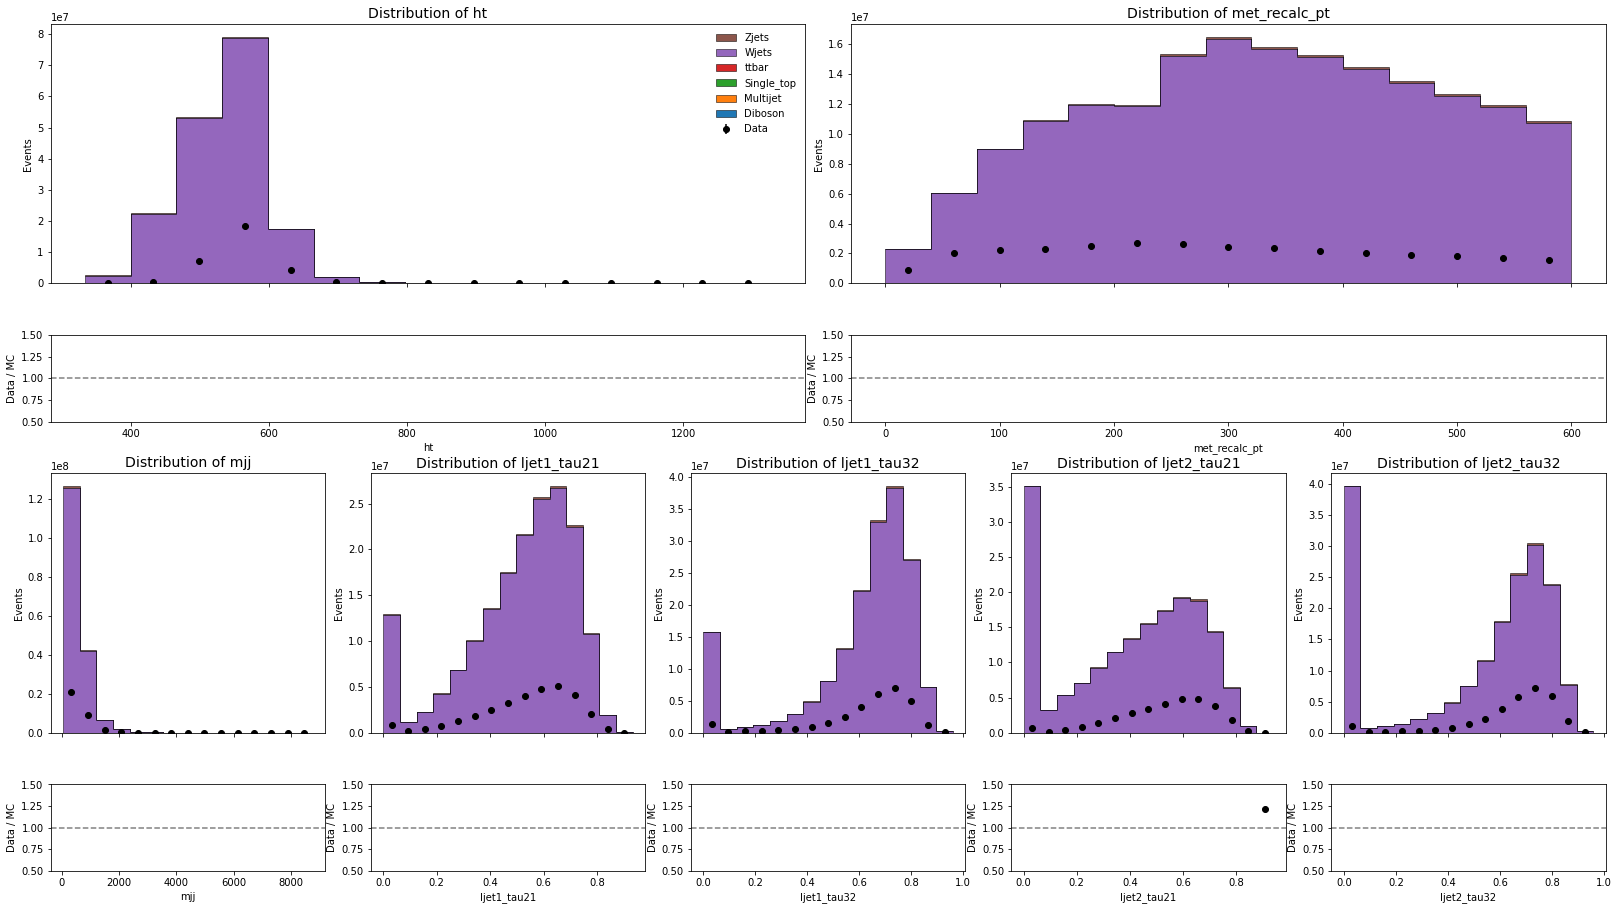

In [78]:
plot_mc_data_comparison(mc_total_df, data_total_df)

Generating plots for: 1-Lepton CR (W+jets dominated)

---  ---
Total Data Yield: 761448
Total MC Yield:   140877943.61
Applying Empirical Norm Factor: 0.00541
----------------------



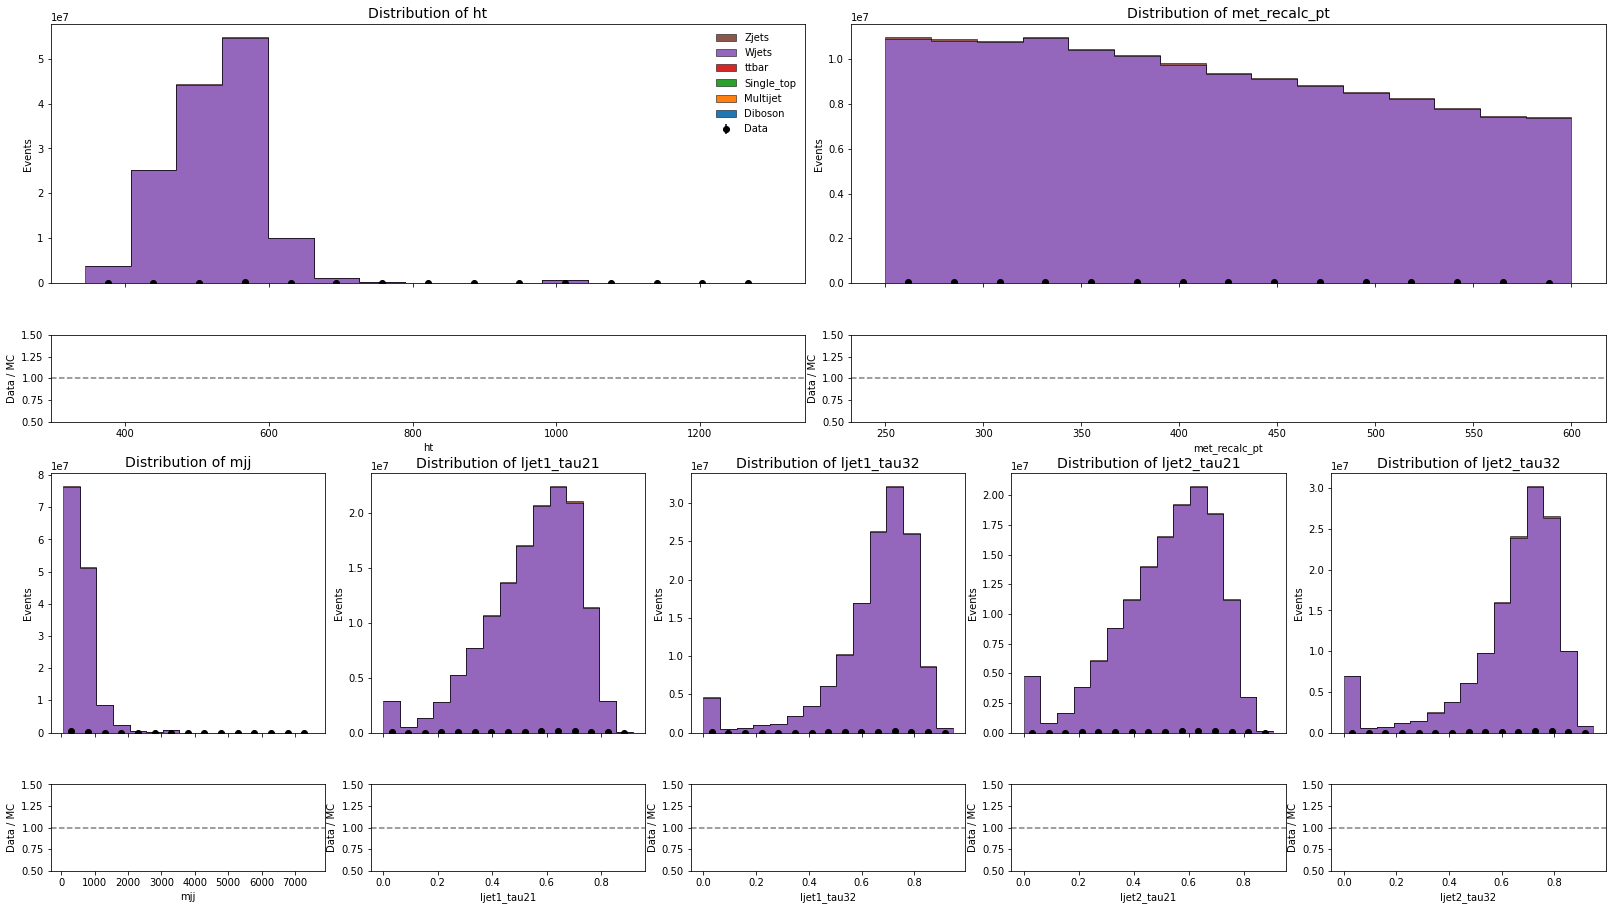

Generating plots for: 1-Lepton 1-Btag CR (Top dominated)

---  ---
Total Data Yield: 749146
Total MC Yield:   69019033.14
Applying Empirical Norm Factor: 0.01085
----------------------



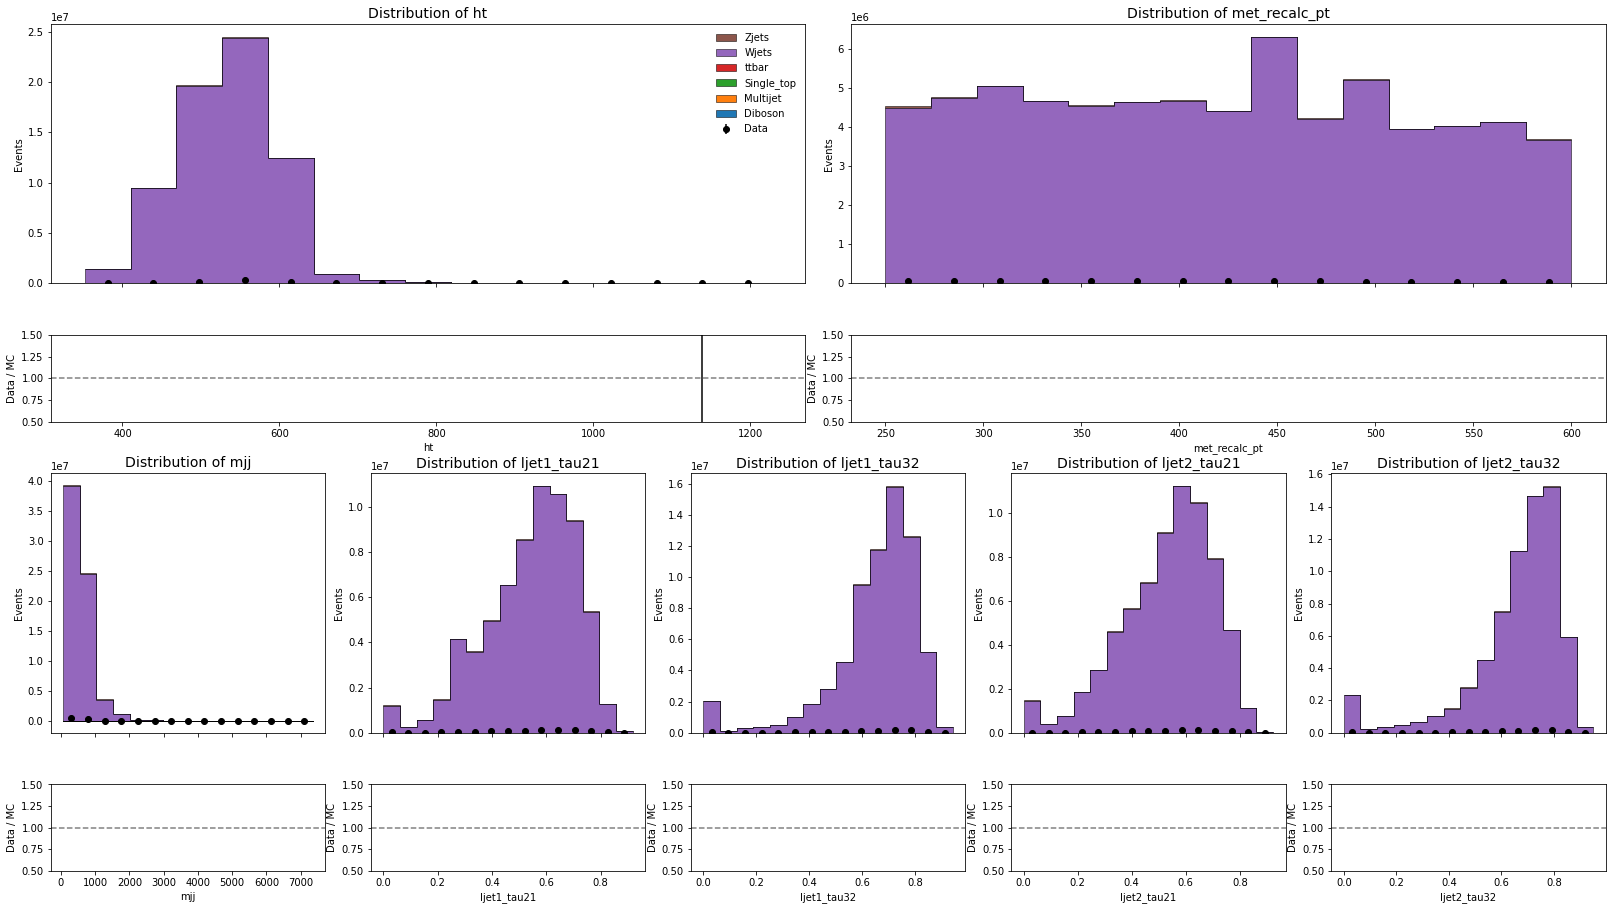

Generating plots for: 2-Lepton CR (Z+jets dominated)

---  ---
Total Data Yield: 43227
Total MC Yield:   65997312.98
Applying Empirical Norm Factor: 0.00065
----------------------



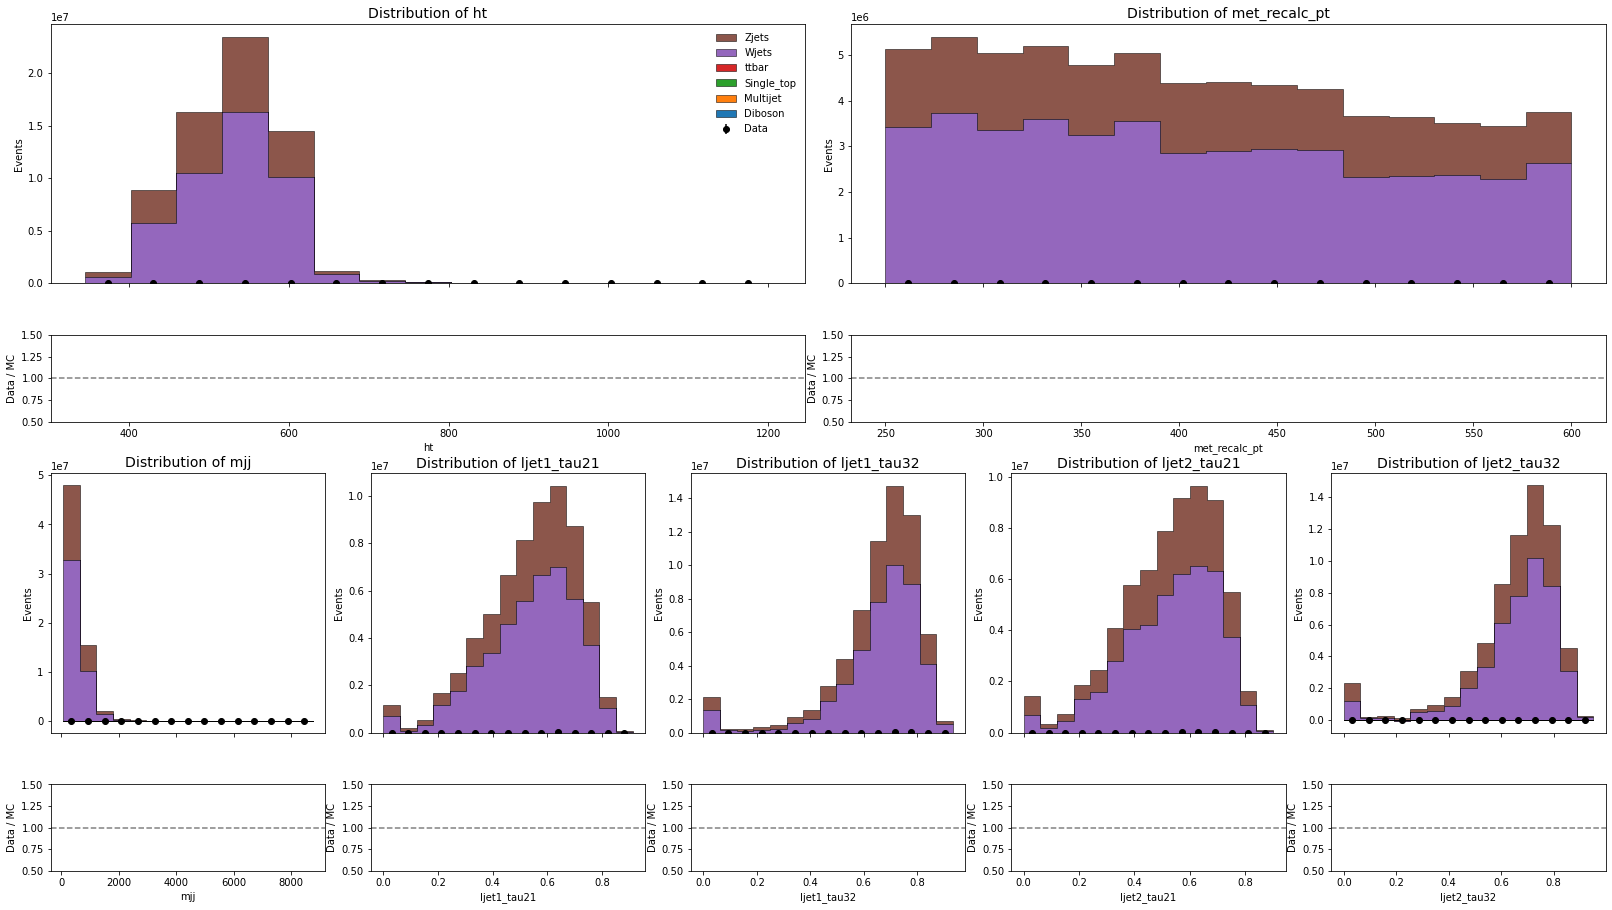

Generating plots for: 0-Lepton CR (Multijet dominated)

---  ---
Total Data Yield: 29690642
Total MC Yield:   204643328.10
Applying Empirical Norm Factor: 0.14508
----------------------



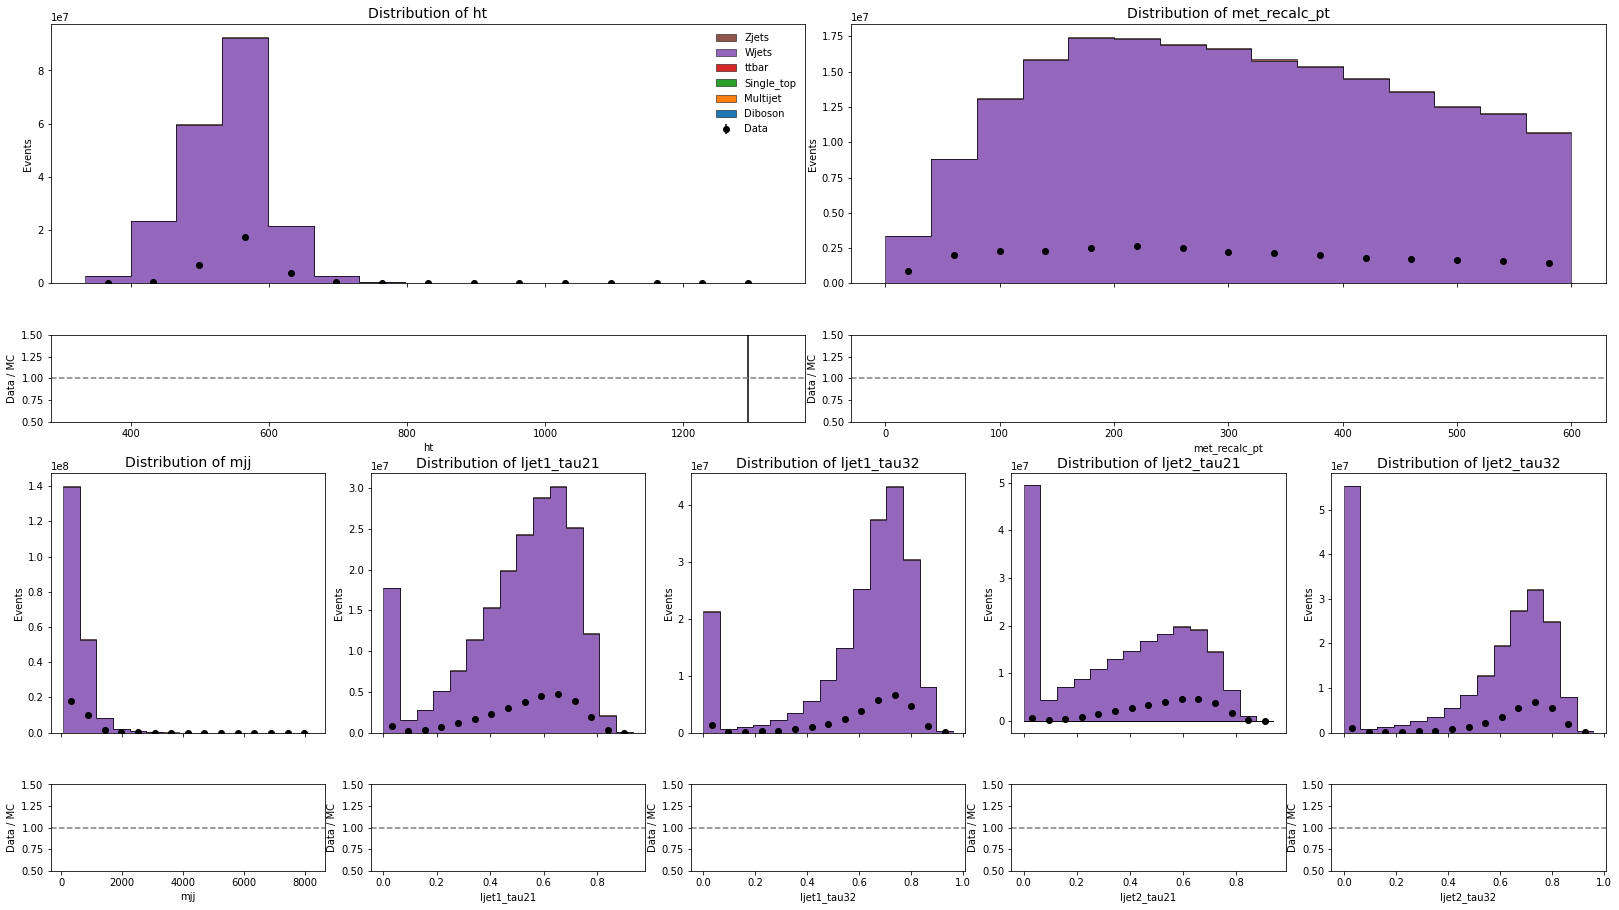

In [79]:
# Group your pre-loaded DataFrames by region
regions = {
    "1-Lepton CR (W+jets dominated)": (MC_CR1L, DATA_CR1L),
    "1-Lepton 1-Btag CR (Top dominated)": (MC_CR1L1B, DATA_CR1L1B),
    "2-Lepton CR (Z+jets dominated)": (MC_CR2L, DATA_CR2L),
    "0-Lepton CR (Multijet dominated)": (MC_CR0L, DATA_CR0L)
}

# Plot each region independently
for region_name, (mc_df, data_df) in regions.items():
    print(f"Generating plots for: {region_name}")
    
    # Optional: You can pass region_name to plot_mc_data_comparison 
    # to use it in your ax_main.set_title() so you know which plot is which!
    plot_mc_data_comparison(mc_df, data_df)